In [31]:
#Set up

#install libraries
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from tueplots import bundles
from tueplots.constants.color import rgb


# set plotting stylesheet
plt.rcParams.update(bundles.icml2024(column='half', nrows=1, ncols=2)) #test different rows and columns
# Set global font sizes before any plotting
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 20,      # Title
    'axes.labelsize': 18,      # Axis labels
    'xtick.labelsize': 16,     # X-axis tick labels
    'ytick.labelsize': 16,     # Y-axis tick labels  
    'legend.fontsize': 18,     # Legend
    'figure.titlesize': 25     # Figure title
})


import sys
print(sys.executable)

#set source and output paths
source_path = '../../data/'
csv_output_path = '../../data/processed/'
figure_output_path = '../../paper/figures/'

#upload raw query data
df_32_raw = pd.read_csv(f'{source_path}repository_queries/500000_32_homicide-female_DE.csv') 
#upload manually tagged articles with json data
df_tag = pd.read_csv(f'{source_path}processed/manual-tag_all_parsedson.csv')
#filter to only ones with T/F data
df_tag_valid = df_tag.dropna(subset=['woman_murdered'])
#upload keyword data
df_key = pd.read_csv(f'{source_path}manual_tag/femicide_keywords.csv')
#upload top k data
df_50 = pd.read_csv(f'{source_path}processed/7-9_22_24_26-27_31-32_2017-2023_top50.csv')
df_25 = pd.read_csv(f'{source_path}processed/7-14_22-24_26-27_29-32_2017-2023_top25.csv')
#final dataset
final = pd.read_csv(f'{source_path}final_dataset_t225.csv')

/Users/madelinemiller/Desktop/data_literacy/geonews_femicide/source/.venv/bin/python


In [25]:
#filters for raw data
#data filtered to only one entry per NUTS and date between 2017 -2023
df_32_raw['NUTS'] = df_32_raw['NUTS'].fillna('').astype(str)
print(f'df 32 raw  shape: {df_32_raw.shape}')
df_32 = df_32_raw.groupby('id').agg({
    'NUTS': lambda x: ', '.join(sorted(set(code for code in x if code.startswith('DE')))),
    'url': 'first',
    'hostname': 'first',
    'date': 'first',
    'cos_dist': 'first', # these values will all be the same
    'hashed_id': 'first',
    'date_crawled': 'first'
    }).reset_index()
#remove null NUTS
df_32 = df_32[df_32['NUTS'].notna()]
df_32 = df_32[df_32['NUTS']!='']

print(f'df 32 nuts condensed shape: {df_32.shape}')
#Convert the date column to datetime objects
df_32['date'] = pd.to_datetime(df_32['date'])      
# Filter for dates
df_32 = df_32[(df_32['date'].dt.year >= 2017) & (df_32['date'].dt.year <= 2023)]
print(f'df 32 date removed shape: {df_32.shape}')
df_32_nothresh = df_32
df_32 = df_32[df_32['cos_dist']<=.225].copy()
print(f'shape of df_32 with threshold: {df_32.shape}')

df 32 raw  shape: (1143913, 13)
df 32 nuts condensed shape: (375215, 8)
df 32 date removed shape: (364570, 8)
shape of df_32 with threshold: (31368, 8)


In [39]:
#select only id
df_sampled = df_tag.dropna(subset=['query_32_cosine_bin', 'woman_murdered']).copy()
#get list of ids
sampled_ids = df_sampled['id']
print(len(sampled_ids))
#filter raw dataset to just those ids
df_32_sampled = df_32_nothresh[df_32_nothresh['id'].isin(sampled_ids)].copy()
print(df_32_sampled.shape)

677
(677, 8)


In [3]:
def removedup_cosdist_source(df):
    #how many total items in dataset have same hostname and cosine distance
    #add column to check article duplicates if the article has the same source and same cosine distance
    df['cos_hostname_duplicate_count'] = df.groupby(['cos_dist', 'hostname'])['cos_dist'].transform('count')

    total_duplicates= df[df['cos_hostname_duplicate_count']>1].shape
    
    # mark retained rows
    df['retained'] = ~df.duplicated(
        subset=['cos_dist', 'hostname'],
        keep='first'
    )
    
    #filter to only rows with duplicates and save csv
    
    df[df['cos_hostname_duplicate_count']>1].to_csv(f'{csv_output_path}duplicate_q32thresh_flagged.csv', index=False)
    
    # keep only retained rows
    df_dupsremoved = df[df['retained']].copy()
    
    print(f'df_dupsremoved: {df_dupsremoved.shape}')
    totaldupsremoved = df.shape[0] - df_dupsremoved.shape[0]
    uniquedups = total_duplicates[0] - totaldupsremoved
    print(f'total duplicates: {total_duplicates[0]}')
    print(f'total_duplicates_removed = {totaldupsremoved}')
    print(f'remaining unique = {uniquedups}')

    return df_dupsremoved

In [4]:
df_32_nodups = removedup_cosdist_source(df_32)
nodup_ids = df_32_nodups['id']

df_tag_nodups = df_tag[df_tag['id'].isin(nodup_ids)]
print(df_tag.shape)
print(df_tag_nodups.shape)

df_dupsremoved: (30195, 10)
total duplicates: 2087
total_duplicates_removed = 1173
remaining unique = 914
(1191, 19)
(604, 19)


In [5]:
def query_relevant_list(df_topk, topk, df_tag, k=None): 
    # join tagging information to top k
    #left join means only articles that were part of topk check are retained
    df_query = df_topk.merge(df_tag[['id', 'woman_murdered','URL_works']], on='id', how='left')
    print(f"\nshape topk: {df_topk.shape}")
    print(f"shape topk tagged: {df_query.shape}")
    # Convert all pd.NA to np.nan in the entire dataframe
    df_query = df_query.fillna(np.nan)

    if k is None:
        k = topk
    
    # Get list of queries
    queries = [col.removeprefix('cos_rank_') for col in df_query.columns if col.startswith('cos_rank_')]
    
    query_list = []  # List to store all query results
    summary_list = []  # List to store summary per query
    
    # For each query: create records with article id, relevance, cosine distance, and rank
    for query in queries:
        rank_col = f'cos_rank_{query}'
        dist_col = f'cos_dist_{query}'

        # Filter to only rows that have previous topk data
        #(we don't want to rank if it wasn't in original topk
        df_query_subset = df_query[df_query[rank_col]<=topk].copy()

        # Create updated ranking (only ranks rows where woman_murdered is not null)
        df_query_subset['new_rank_dense'] = np.nan  # Initialize with NaN
        mask = df_query_subset['woman_murdered'].notna()  # Identify rows to rank
        df_query_subset.loc[mask, 'new_rank'] = (
            df_query_subset.loc[mask, dist_col]
                .rank(method='dense', na_option='keep')
                .astype(float)
        )

        df_query_subset['new_rank_min'] = np.nan  # Initialize with NaN
        mask = df_query_subset['woman_murdered'].notna()  # Identify rows to rank
        df_query_subset.loc[mask, 'new_rank_min'] = (
            df_query_subset.loc[mask, dist_col]
                .rank(method='min', na_option='keep')
                .astype(float)
        )
  
        # Normalized cosine distance
        df_query_subset['mstd_norm_cos_dist'] = (df_query_subset[dist_col] - df_query_subset[dist_col].mean()) / df_query_subset[dist_col].std()
        min_val = df_query_subset[dist_col].min()
        max_val = df_query_subset[dist_col].max()
        range_val = max_val - min_val
        df_query_subset['minshift_norm_cos_dist'] = df_query_subset[dist_col] - min_val
        df_query_subset['minmax_norm_cos_dist'] = (df_query_subset[dist_col] - min_val) / range_val

        # Create records for THIS query only (create temporary list)
        current_query_records = []
    
        for _, row in df_query_subset.iterrows():
            record = {
                'query': query,
                'article_id': row['id'],
                'relevance': row['woman_murdered'],
                'cosine_distance': row[dist_col],
                'original_rank': row[rank_col],
                'new_rank': row['new_rank'],
                'new_rank_min': row['new_rank_min'],
                'url_works': row['URL_works'], 
                'mstd_norm_cos_dist': row['mstd_norm_cos_dist'],
                'minshift_norm_cos_dist': row['minshift_norm_cos_dist'], 
                'minmax_norm_cos_dist': row['minmax_norm_cos_dist'] 
            }

            query_list.append(record)
            current_query_records.append(record) 
        
      # Create summary for query using current_query_records
        relevant = sum(1 for r in current_query_records if r['relevance'] == True)
        irrelevant = sum(1 for r in current_query_records if r['relevance'] == False)
        not_checkable = sum(1 for r in current_query_records if pd.isna(r['relevance']))
        
        # Calculate additional summary stats
        original_ranks = [r['original_rank'] for r in current_query_records if not pd.isna(r['original_rank'])]
        new_ranks = [r['new_rank'] for r in current_query_records if not pd.isna(r['new_rank'])]
        
        relevant_norankdups = sum(1 for r in current_query_records 
                                  if r['relevance'] == True 
                                  and isinstance(r.get('new_rank_min'), (int, float))  # only numeric
                                  and r['new_rank_min'] <= k)
        irrelevant_norankdups = sum(1 for r in current_query_records 
                                    if r['relevance'] == False 
                                    and isinstance(r.get('new_rank_min'), (int, float))  # only numeric
                                    and r['new_rank_min'] <= k)
       
        summary_list.append({
            'query': query,
            'total_articles': len(current_query_records),
            'relevant_count': relevant,
            'irrelevant_count': irrelevant,
            'relevant_norankdups': relevant_norankdups,
            'irrelevant_norankdups': irrelevant_norankdups,
            'not_checked_count': not_checkable,
            'total_valid': relevant+irrelevant
        })
    
    # Convert to DataFrames
    df_individual = pd.DataFrame(query_list)
    df_summary = pd.DataFrame(summary_list)
    
    # Print summary
    print(f"Total records created: {len(query_list)}")
    print(f"Number of queries: {len(queries)}")
    
    return queries, df_individual, df_summary

In [6]:
df_50_querylist, df_50_individual, df_50_summary  = query_relevant_list(df_50, topk=50, df_tag=df_tag_valid)
df_25_querylist, df_25_individual, df_25_summary = query_relevant_list(df_25, topk=25, df_tag=df_tag_valid)
df_25_summary.head(18).sort_values(by='total_valid', ascending=False)


shape topk: (306, 24)
shape topk tagged: (306, 26)
Total records created: 450
Number of queries: 9

shape topk: (263, 40)
shape topk tagged: (263, 42)
Total records created: 425
Number of queries: 17


,query,total_articles,relevant_count,irrelevant_count,relevant_norankdups,irrelevant_norankdups,not_checked_count,total_valid
6,13_victim-woman-long_EN,25,0,25,0,25,0,25
0,7_police-report-gender-motivated_EN,25,24,0,24,0,1,24
16,32_homicide-female_DE,25,24,0,24,0,1,24
13,29_woman-was-murdered_DE,25,23,0,23,0,2,23
14,30_woman-was-killed_DE,25,23,0,23,0,2,23
5,12_murder-woman-victim_DE,25,10,12,10,12,3,22
2,9_woman-girl-killed_EN,25,22,0,22,0,3,22
1,8_police-report-gender-motivated_DE,25,17,5,17,5,3,22
9,23_femicide_Frauenmord_DE,25,9,13,9,13,3,22
15,31_murder-woman-girl_DE,25,16,6,16,6,3,22


In [7]:
df_50_individual.to_csv(f'{csv_output_path}test.csv', index=False)
df_50_summary.head(18)

,query,total_articles,relevant_count,irrelevant_count,relevant_norankdups,irrelevant_norankdups,not_checked_count,total_valid
0,7_police-report-gender-motivated_EN,50,43,0,43,0,7,43
1,8_police-report-gender-motivated_DE,50,30,14,30,14,6,44
2,9_woman-girl-killed_EN,50,32,1,32,1,17,33
3,22_femicide_Femizid_DE,50,13,24,13,24,13,37
4,24_femicide_Feminizid_DE,50,9,31,9,31,10,40
5,26_femicide_Femicide_EN,50,18,25,18,25,7,43
6,27_femicide_femicide_EN,50,19,24,19,24,7,43
7,31_murder-woman-girl_DE,50,31,13,31,13,6,44
8,32_homicide-female_DE,50,45,0,45,0,5,45


## Precision@k

$$
\text{Precision@k} = \frac{1}{k} \sum_{i=1}^{k} \text{rel}_i
$$

In [8]:
def precisionk(k, df_topk, topk, nodups = False):
    #filter to rank >= k
    _, _, df_summary_k = query_relevant_list(df_topk=df_topk, df_tag=df_tag_nodups, topk=topk,k=k)
        
    print(f'shape df_summary_k: {df_summary_k.shape}')
    #calculate accuracy
    if nodups == True: 
        total = df_summary_k['relevant_norankdups'] + df_summary_k['irrelevant_norankdups']
        mask = total >= k
        df_summary_k.loc[mask, f'precision{k}'] = (
            df_summary_k.loc[mask, 'relevant_norankdups'] / 
            (df_summary_k.loc[mask, 'irrelevant_norankdups'] + df_summary_k.loc[mask, 'relevant_norankdups']))
    else: 
        total = df_summary_k['relevant_count'] + df_summary_k['irrelevant_count']
        print(total)
        mask = total >= k
        df_summary_k.loc[mask, f'precision{k}'] = (
            df_summary_k.loc[mask, 'relevant_count'] / 
            (df_summary_k.loc[mask, 'irrelevant_count'] + df_summary_k.loc[mask, 'relevant_count']))

    print(f'shape df_summary_k w prec: {df_summary_k.shape}')
    
    return df_summary_k

In [9]:
k = 10
df25_precisionk1 = precisionk(k=k, df_topk = df_25, topk=25, nodups = False)

df25_precisionk1.sort_values(by=[f'precision{k}'], ascending=False)




shape topk: (263, 40)
shape topk tagged: (263, 42)
Total records created: 425
Number of queries: 17
shape df_summary_k: (17, 8)
0     17
1     10
2     19
3     17
4     21
5     19
6     10
7     13
8     15
9     21
10    13
11    17
12    17
13    23
14    23
15    17
16    24
dtype: int64
shape df_summary_k w prec: (17, 9)


,query,total_articles,relevant_count,irrelevant_count,relevant_norankdups,irrelevant_norankdups,not_checked_count,total_valid,precision10
0,7_police-report-gender-motivated_EN,25,17,0,10,0,8,17,1.000000
13,29_woman-was-murdered_DE,25,23,0,10,0,2,23,1.000000
14,30_woman-was-killed_DE,25,23,0,14,0,2,23,1.000000
16,32_homicide-female_DE,25,24,0,10,0,1,24,1.000000
2,9_woman-girl-killed_EN,25,19,0,10,0,6,19,1.000000
3,10_woman-girl-killed_DE,25,14,3,10,3,8,17,0.823529
4,11_murder-woman-victim_EN,25,17,4,7,3,4,21,0.809524
1,8_police-report-gender-motivated_DE,25,8,2,8,2,15,10,0.800000
15,31_murder-woman-girl_DE,25,12,5,7,3,8,17,0.705882
9,23_femicide_Frauenmord_DE,25,9,12,4,6,4,21,0.428571


In [10]:
k = 25
df50_precisionk1 = precisionk(k=k, df_topk = df_50, topk=50, nodups=False)

df50_precisionk1.sort_values(by=[f'precision{k}'], ascending=False)


shape topk: (306, 24)
shape topk tagged: (306, 26)
Total records created: 450
Number of queries: 9
shape df_summary_k: (9, 8)
0    34
1    18
2    28
3    25
4    28
5    29
6    32
7    36
8    45
dtype: int64
shape df_summary_k w prec: (9, 9)


,query,total_articles,relevant_count,irrelevant_count,relevant_norankdups,irrelevant_norankdups,not_checked_count,total_valid,precision25
0,7_police-report-gender-motivated_EN,50,34,0,25,0,16,34,1.000000
8,32_homicide-female_DE,50,45,0,25,0,5,45,1.000000
2,9_woman-girl-killed_EN,50,27,1,25,0,22,28,0.964286
7,31_murder-woman-girl_DE,50,25,11,17,8,14,36,0.694444
5,26_femicide_Femicide_EN,50,14,15,12,13,21,29,0.482759
6,27_femicide_femicide_EN,50,15,17,12,13,18,32,0.468750
3,22_femicide_Femizid_DE,50,9,16,9,16,25,25,0.360000
4,24_femicide_Feminizid_DE,50,7,21,6,21,22,28,0.250000
1,8_police-report-gender-motivated_DE,50,14,4,14,4,32,18,NaN


In [11]:
def add_jitter_if_duplicates(ranks, y_pos, jitter_amount=0.15):
    """Add vertical jitter only to ranks that have duplicates"""
    y_positions = np.array([y_pos] * len(ranks), dtype=float)
    
    if len(ranks) == 0:
        return y_positions
    
    # Find which ranks have duplicates
    unique_ranks, counts = np.unique(ranks, return_counts=True)
    duplicate_ranks = unique_ranks[counts > 1]
    
    # Add jitter only to duplicate ranks, but keep one point at original position
    for rank in duplicate_ranks:
        mask = ranks == rank
        duplicate_indices = np.where(mask)[0]
        num_duplicates = len(duplicate_indices)
        
        # Keep first point unjittered, jitter the rest
        if num_duplicates > 1:
            # Jitter all except the first one
            jitter_values = np.random.uniform(-jitter_amount, jitter_amount, num_duplicates - 1)
            y_positions[duplicate_indices[1:]] += jitter_values
    
    return y_positions


def plot_query_outcomes(df_individual, x_col='cos_rank_', rel_col ='new_rank' , 
                        mainquery=None, threshold=None, tagdata=None, lengthstart=0, lengthend=1, jitter_amount=0.15, n=50):
    # Convert list to dataframe for easier grouping
    queries = df_individual['query'].unique()
    
    fig, ax = plt.subplots(figsize=(18, len(queries) * 0.8))
    
    for i, query in enumerate(queries):
        y_pos = i
        x_col = f'{x_col}{query}'
        
        # Filter data for this query
        query_subset = df_individual[df_individual['query'] == query]

        if mainquery is not None and threshold is not None and tagdata is not None:
            column = f'{x_col}{mainquery}'  
            excluded_ids = tagdata[tagdata[column] >= threshold]['id'].values
            
            relevant_subset = tagdata['woman_murdered'] == True
            excluded_subset = tagdata['id'].isin(excluded_ids)
            
            rel_excl = tagdata[relevant_subset & excluded_subset][x_col].values
            irrel_excl = tagdata[~relevant_subset & excluded_subset][x_col].values
            
            # Add jitter only if duplicates exist
            rel_excl_y = add_jitter_if_duplicates(rel_excl, y_pos, jitter_amount)
            irrel_excl_y = add_jitter_if_duplicates(irrel_excl, y_pos, jitter_amount)
            
            ax.plot(rel_excl, rel_excl_y,
                    's', alpha=0.7, color='orange', ms=6, mec='black', mew=1.5,
                    label=f'Relevant ({mainquery} excluded)' if i == 0 else '')
            ax.plot(irrel_excl, irrel_excl_y,
                    's', alpha=0.7, color='blue', ms=6, mec='black', mew=1.5,
                    label=f'Irrelevant ({mainquery} excluded)' if i == 0 else '')
        
        # Get relevant and irrelevant from the list/dataframe
        relevant = query_subset[query_subset['relevance'] == True][rel_col].values
        irrelevant = query_subset[query_subset['relevance'] == False][rel_col].values
        na = query_subset.loc[query_subset['relevance'].isna(), rel_col].values
        
        # Add jitter only if duplicates exist
        relevant_y = add_jitter_if_duplicates(relevant, y_pos, jitter_amount)
        irrelevant_y = add_jitter_if_duplicates(irrelevant, y_pos, jitter_amount)
        na_y = add_jitter_if_duplicates(na, y_pos, jitter_amount)
        
        ax.plot(relevant, relevant_y,
                'o', alpha=0.6, color=rgb.tue_orange, ms=7, mec='none', 
                label='Relevant' if i == 0 else '')
        ax.plot(irrelevant, irrelevant_y,
                'o', alpha=0.6, color=rgb.tue_blue, ms=7, mec='none', 
                label='Irrelevant' if i == 0 else '')
        ax.plot(na, na_y,
                'o', alpha=0.6, color=rgb.tue_gray, ms=7, mec='none', 
                label='NA' if i == 0 else '')
        
        all = np.concatenate([relevant, irrelevant, na])

        
        # Sort by rel_col to find nth point, excluding NA values
        query_subset_filtered = query_subset[query_subset['relevance'] == True]
        query_subset_sorted = query_subset_filtered.sort_values(rel_col)
        
        # Find where the nth point falls (based on rel_col)
        if len(query_subset_sorted) >= n:
            # Get the rel_col value at the 15th position when sorted by sort_col
            rank_at_nth = query_subset_sorted.iloc[n-1][rel_col]  # nth point (0-indexed)
            
            # Draw vertical line at this value for this query only
            ax.axvline(rank_at_nth, 
                      ymin=(y_pos - 0.4 + 0.5) / len(queries), 
                      ymax=(y_pos + 0.4 + 0.5) / len(queries),
                      color= rgb.tue_red, linestyle='-', linewidth=2, alpha=0.7,
                      label=f'{n}th article' if i == 0 else '')
        
    ax.set_yticks(range(len(queries)))
    ax.set_yticklabels(queries)
    
    for i in range(len(queries)):
        if i > 0:
            ax.axhline(i - 0.5, color='gray', alpha=0.3, linewidth=0.5)
    
    ax.set_xlabel(f'{rel_col}')
    ax.set_xlim(lengthstart, lengthend)
    ax.set_ylim(-0.5, len(queries) - 0.5)
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right')
    ax.set_title(f"Article {rel_col} by Query with Relevance", pad=20)

    return fig, ax

In [12]:
df_50_individual.columns

Index(['query', 'article_id', 'relevance', 'cosine_distance', 'original_rank',
       'new_rank', 'new_rank_min', 'url_works', 'mstd_norm_cos_dist',
       'minshift_norm_cos_dist', 'minmax_norm_cos_dist'],
      dtype='object')

/var/folders/8y/qtlvpscd259873sjdt05kvlm0000gn/T/ipykernel_8341/2066966951.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


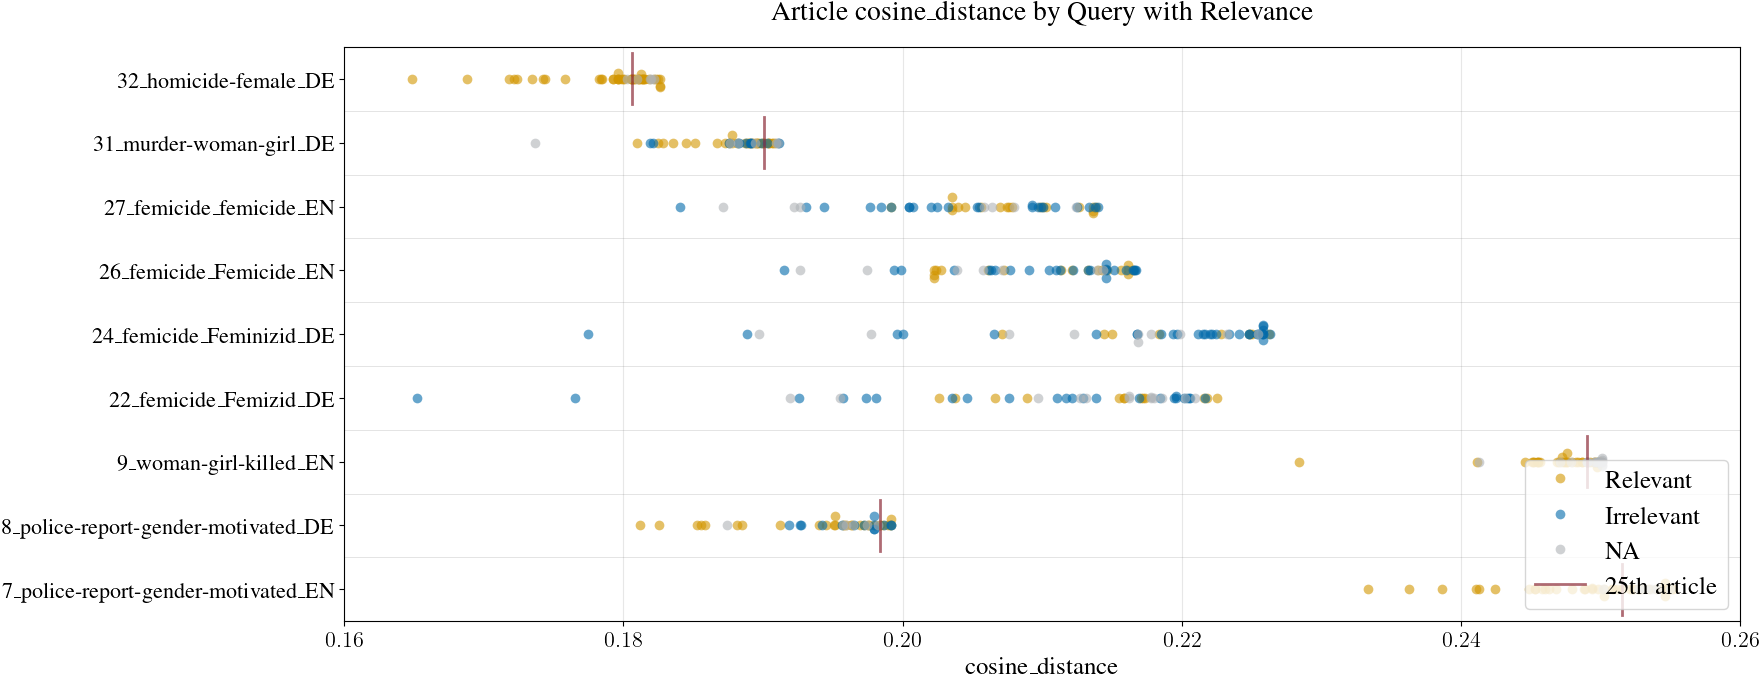

In [13]:
fig,_ = plot_query_outcomes(df_50_individual, x_col='cos_dist_', rel_col ='cosine_distance' , 
                        mainquery=None, threshold=None, tagdata=None, lengthstart=.16, lengthend=.26,n=25)
plt.tight_layout()
fig.savefig(f"{figure_output_path}fig_timeseries_icml.pdf", bbox_inches="tight")

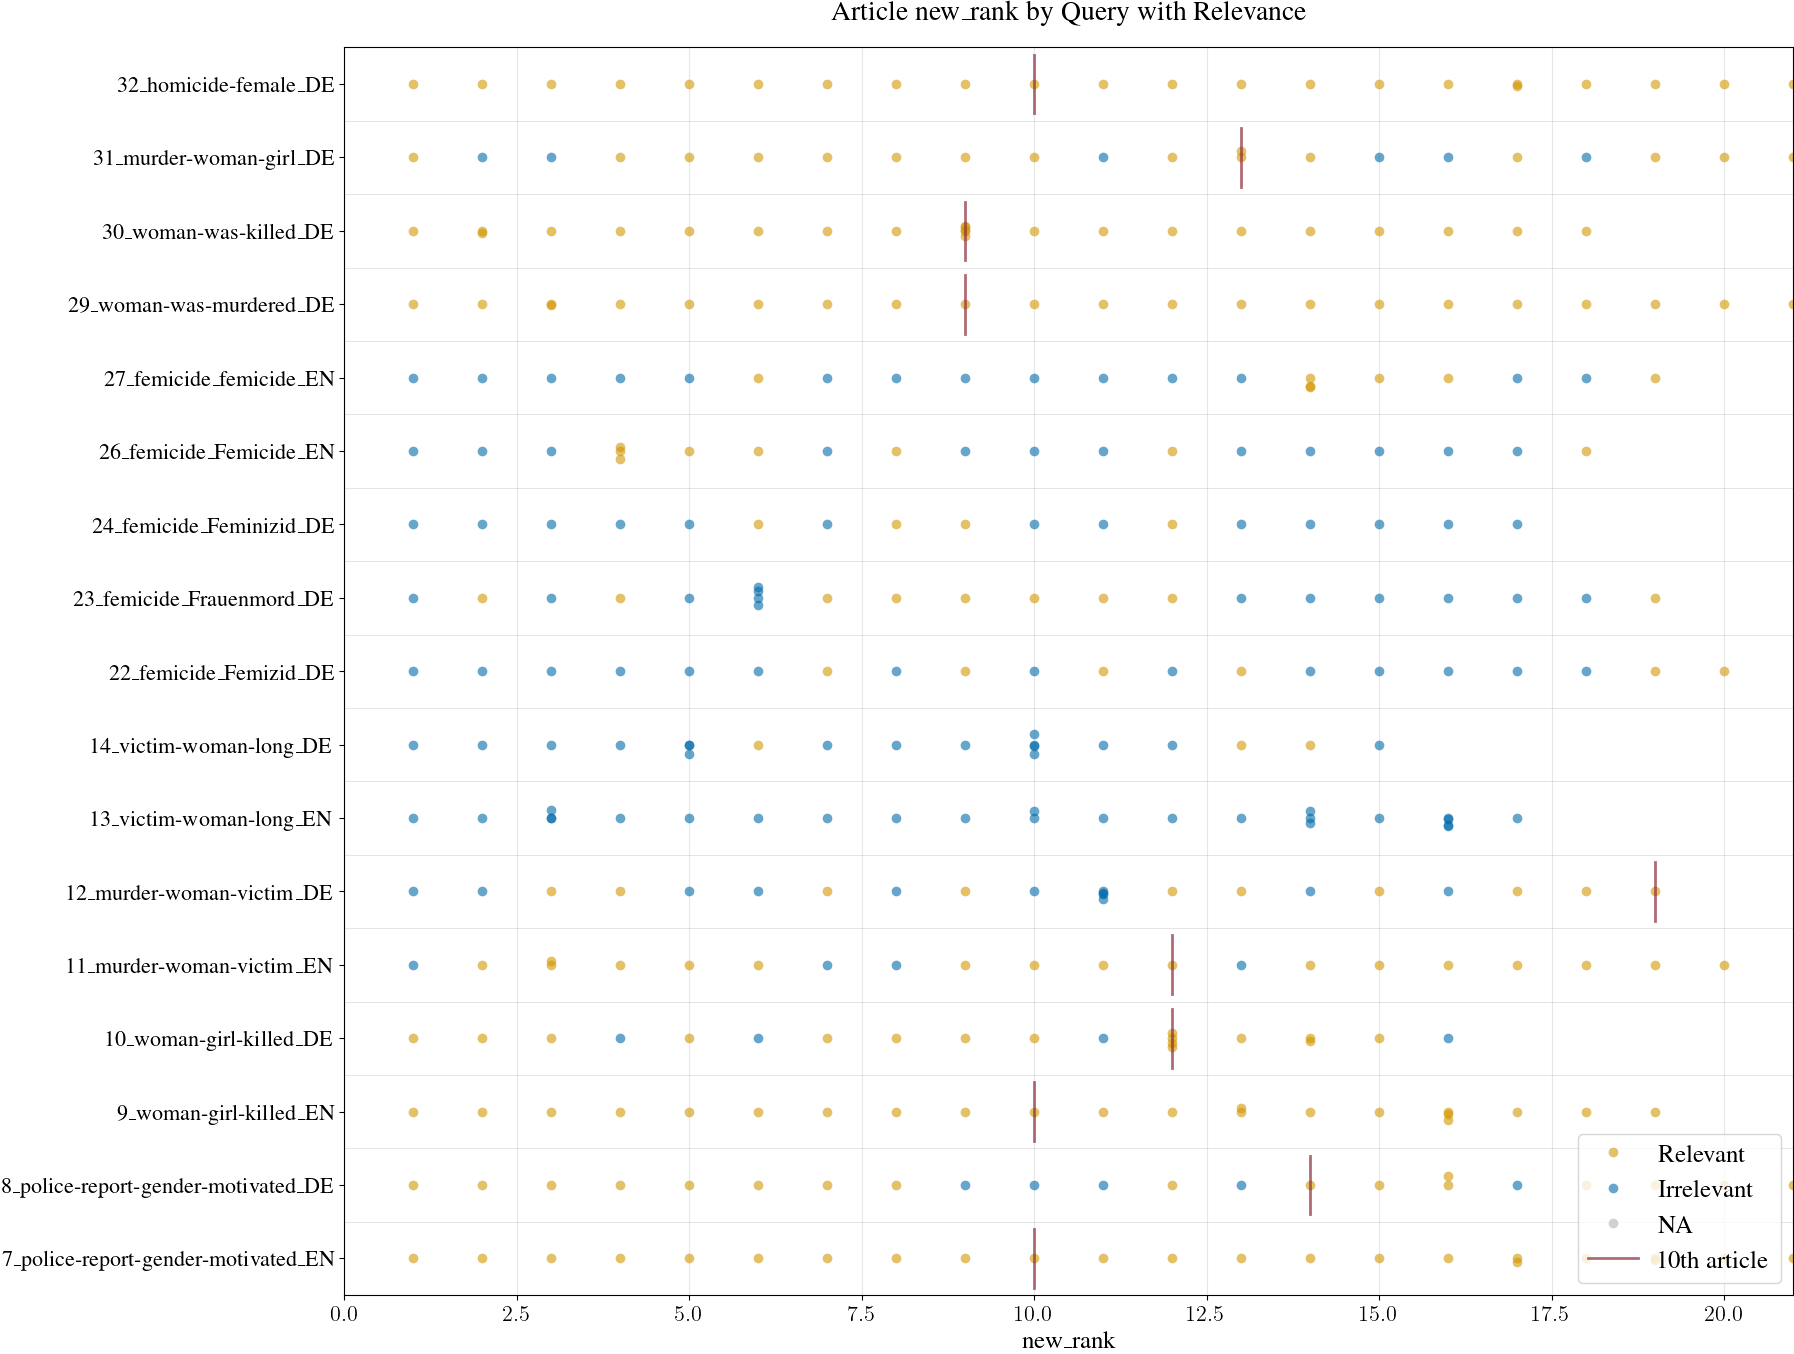

In [14]:
fig,_ = plot_query_outcomes(df_25_individual, x_col='cos_rank_', rel_col ='new_rank' , 
                        mainquery=None, threshold=None, tagdata=None, lengthstart=0, lengthend=21,n=10)

In [15]:
def plot_cos_outcomes(df_individual, x_col='cos_dist_', rel_col ='cos_dist_' , query_order=None, query_order_labels=None,
                        mainquery=None, threshold=None, tagdata=None, lengthstart=0, lengthend=1, jitter_amount=0.15, n=50):
    # Convert list to dataframe for easier grouping
    #queries = df_individual['query'].unique()
    
    fig, ax = plt.subplots(figsize=(10, len(query_order) * 0.8))
    
    for i, query in enumerate(query_order):
        y_pos = i
        x_col = f'{x_col}{query}'

        # Filter data for this query
        query_subset = df_individual[df_individual['query'] == query]

        # Get relevant and irrelevant from the list/dataframe
        relevant = query_subset[query_subset['relevance'] == True][rel_col].values
        irrelevant = query_subset[query_subset['relevance'] == False][rel_col].values
        na = query_subset.loc[query_subset['relevance'].isna(), rel_col].values
        
        n_r = relevant.shape[0] # number of relevant articles
        n_i = irrelevant.shape[0] # number of irrelevant articles
        n_na = na.shape[0] # number of na articles
        
        u_r = np.random.rand(n_r)  
        u_i = np.random.rand(n_i)  
        u_na = np.random.rand(n_na)  
        
        ax.plot(relevant, -.4 * u_r+y_pos,
                'o', alpha=0.6, color=rgb.tue_orange, ms=7, mec='none', 
                label='Relevant' if i == 0 else '')
        ax.plot(irrelevant, .4*u_i+y_pos,
                'o', alpha=0.6, color=rgb.tue_blue, ms=7, mec='none', 
                label='Irrelevant' if i == 0 else '')
        ax.plot(na, -.001 * u_na+y_pos,
                'o', alpha=0.6, color=rgb.tue_gray, ms=7, mec='none', 
                label='NaN' if i == 0 else '')
        
        all = np.concatenate([relevant, irrelevant, na])
        
        # Sort by rel_col to find nth point, excluding NA values
        query_subset_filtered = query_subset[
            (query_subset['relevance'] == True) | (query_subset['relevance'] == False)
            ]
        query_subset_sorted = query_subset_filtered.sort_values(rel_col)
        
        # Find where the nth point falls (based on rel_col)
        if len(query_subset_sorted) >= n:
            # Get the rel_col value at the 15th position when sorted by sort_col
            rank_at_nth = query_subset_sorted.iloc[n-1][rel_col]  # nth point (0-indexed)
            
            # Draw vertical line at this value for this query only
            ax.plot(
                [rank_at_nth, rank_at_nth],
                [y_pos - 0.4, y_pos + 0.4],
                color=rgb.tue_red,
                linewidth=2,
                alpha=0.7,
                label=f'{n}th not NaN Article' if i == 0 else ''
            )
        
    ax.set_yticks(range(len(query_order)))
    ax.set_yticklabels(query_order_labels)
    
    for i in range(len(query_order)):
        if i > 0:
            ax.axhline(i - 0.5, color='gray', alpha=0.3, linewidth=0.5)
    
    ax.set_xlabel(f'{rel_col}')
    ax.set_xlim(lengthstart, lengthend)
    ax.set_ylim(-0.5, len(query_order) - 0.5)
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right')
    ax.set_title(f"Article Cosine Distance by Query with Relevance", pad=20)
    ax.invert_yaxis()#reverse so that query order is correct

    return fig, ax

/var/folders/8y/qtlvpscd259873sjdt05kvlm0000gn/T/ipykernel_8341/4293229832.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


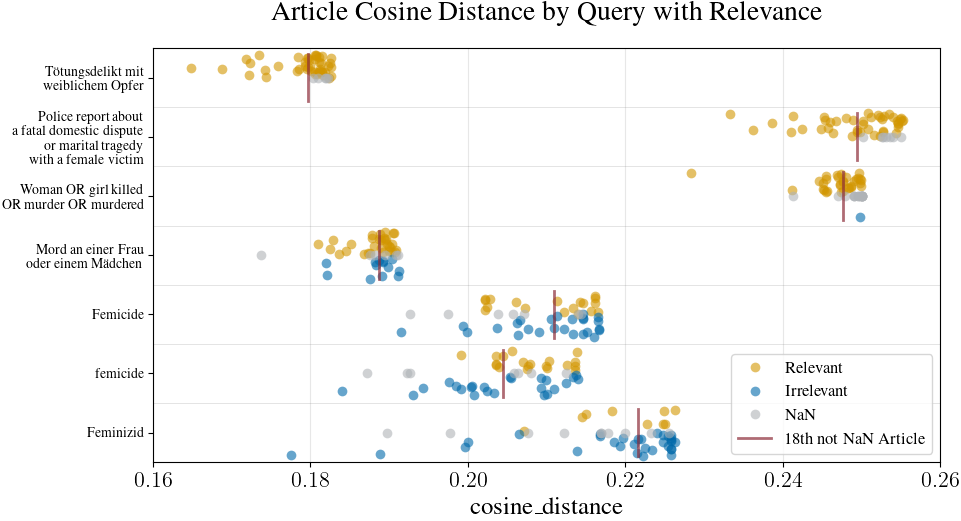

In [44]:
plt.rcParams.update(bundles.icml2024(column='half', nrows=1, ncols=2))
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 20,      # Title
    'axes.labelsize': 18,      # Axis labels
    'xtick.labelsize': 16,     # X-axis tick labels
    'ytick.labelsize': 10,     # Y-axis tick labels  
    'legend.fontsize': 12,     # Legend
    'figure.titlesize': 20     # Figure title
})

query_order_50 = [
    '32_homicide-female_DE',
    '7_police-report-gender-motivated_EN',
    '9_woman-girl-killed_EN',
    '31_murder-woman-girl_DE',
    '26_femicide_Femicide_EN',
    '27_femicide_femicide_EN',
    '24_femicide_Feminizid_DE'
    ]

query_order_50_labels = [
    'Tötungsdelikt mit\nweiblichem Opfer',
    'Police report about\na fatal domestic dispute\nor marital tragedy\nwith a female victim',
    'Woman OR girl killed\nOR murder OR murdered',
    'Mord an einer Frau \noder einem Mädchen',
    'Femicide',
    'femicide',
    'Feminizid'
    ]

fig,_ = plot_cos_outcomes(df_50_individual, x_col='cos_dist_', rel_col ='cosine_distance' , query_order = query_order_50, 
                        query_order_labels = query_order_50_labels,
                        mainquery=None, threshold=None, tagdata=None, lengthstart=.16, lengthend=.26,n=18)
plt.tight_layout()
fig.savefig(f"{figure_output_path}fig_cosdist_querycomp_50_gnf.pdf", bbox_inches="tight")

/var/folders/8y/qtlvpscd259873sjdt05kvlm0000gn/T/ipykernel_8341/2098994490.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


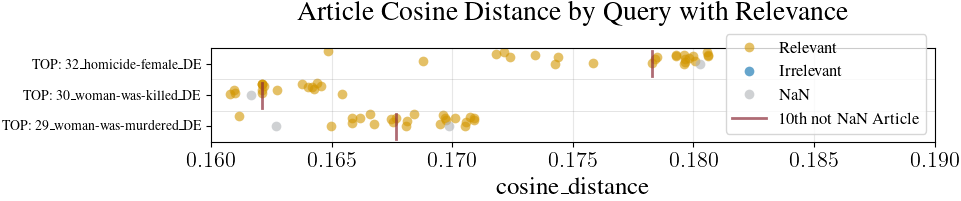

In [43]:
plt.rcParams.update(bundles.icml2024(column='half', nrows=1, ncols=2))
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 20,      # Title
    'axes.labelsize': 18,      # Axis labels
    'xtick.labelsize': 16,     # X-axis tick labels
    'ytick.labelsize': 10,     # Y-axis tick labels  
    'legend.fontsize': 12,     # Legend
    'figure.titlesize': 20     # Figure title
})

query_order_25 = [
    "32_homicide-female_DE",
    #"9_woman-girl-killed_EN",
    #"10_woman-girl-killed_DE",
    #"7_police-report-gender-motivated_EN",
    #"8_police-report-gender-motivated_DE",
    "30_woman-was-killed_DE",
    "29_woman-was-murdered_DE",
    #"23_femicide_Frauenmord_DE",
    #"12_murder-woman-victim_DE",
    #"13_victim-woman-long_EN",
    #"14_victim-woman-long_DE",
    ]

query_order_25_labels = [
    "TOP: 32_homicide-female_DE",
    #"TOP: 9_woman-girl-killed_EN",
    #"10_woman-girl-killed_DE",
    #"TOP: 7_police-report-gender-motivated_EN",
    #"8_police-report-gender-motivated_DE",
    "TOP: 30_woman-was-killed_DE",
    "TOP: 29_woman-was-murdered_DE",
    #"Frauenmord_DE",
    #"12_murder-woman-victim_DE",
    #"13_victim-woman-long_EN",
    #"14_victim-woman-long_DE",
    ]

fig,_ = plot_cos_outcomes(df_25_individual, x_col='cos_dist_', rel_col ='cosine_distance' , query_order = query_order_25, 
                        query_order_labels = query_order_25_labels,
                        mainquery=None, threshold=None, tagdata=None, lengthstart=.16, lengthend=.19,n=10)
plt.tight_layout()
fig.savefig(f"{figure_output_path}fig_cosdist_querycomp_50_gnf.pdf", bbox_inches="tight")

In [33]:
def cos_bin_check(df, df_tag): 

    # Filter to only t/f results
    # Filter out nan for 'woman_murdered' in tagged results
    df_checked_tag = df_tag[df_tag['woman_murdered'].notna()].copy()
    
    # Get list of ids
    checked_ids = df_checked_tag['id']
    
    # Filter dataset to just those ids
    df_query = df[df['id'].isin(checked_ids)].copy()  # Changed from df_query to df
    
    # Sort all checked into bins (add cosine bin row)
    df_query['all_cosine_bin'] = pd.cut(
        df_query['cos_dist'],
        bins=[0.16, 0.18, 0.20, 0.22, 0.24, 0.26, 0.28, np.inf],
        labels=['(0.16, 0.18]', '(0.18, 0.2]', '(0.2, 0.22]', 
                '(0.22, 0.24]', '(0.24, 0.26]', '(0.26, 0.28]', '(0.28+)']
    )
    
    # Merge the bin information back to df_checked_tag
    df_checked_tag = df_checked_tag.merge(
        df_query[['id', 'all_cosine_bin']], 
        on='id', 
        how='left'
    )
    
    # Check result
    print(df_checked_tag['all_cosine_bin'].value_counts())
    
    # Count relevant and not relevant per bin
    bin_counts = df_checked_tag.groupby(['all_cosine_bin', 'woman_murdered'], observed=True).size().reset_index(name='count')
    
    print(bin_counts)
    
    # Sort bins numerically
    bin_order = ['(0.16, 0.18]', '(0.18, 0.2]', '(0.2, 0.22]', '(0.22, 0.24]', '(0.24, 0.26]', '(0.26, 0.28]', '(0.28+)']
    bin_counts['all_cosine_bin'] = pd.Categorical(bin_counts['all_cosine_bin'], categories=bin_order, ordered=True)
    bin_counts = bin_counts.sort_values('all_cosine_bin')
    
    # Plotting
    fig = plt.figure(figsize=(5,4))
    sns.barplot(
        data=bin_counts,
        x='all_cosine_bin',
        y='count',
        hue='woman_murdered'
    )
    plt.title('Relevant vs. Not Relevant Samples per Cosine Bin')
    plt.xlabel('Cosine Distance Bin')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45)
    plt.legend(title='Relevance')
    
    return fig

all_cosine_bin
(0.18, 0.2]     136
(0.26, 0.28]    132
(0.2, 0.22]     131
(0.22, 0.24]    130
(0.24, 0.26]    128
(0.16, 0.18]     20
(0.28+)           0
Name: count, dtype: int64
   all_cosine_bin  woman_murdered  count
0    (0.16, 0.18]            True     20
1     (0.18, 0.2]           False      1
2     (0.18, 0.2]            True    135
3     (0.2, 0.22]           False     10
4     (0.2, 0.22]            True    121
5    (0.22, 0.24]           False     32
6    (0.22, 0.24]            True     98
7    (0.24, 0.26]           False     87
8    (0.24, 0.26]            True     41
9    (0.26, 0.28]           False    114
10   (0.26, 0.28]            True     18


/var/folders/8y/qtlvpscd259873sjdt05kvlm0000gn/T/ipykernel_8341/3588247661.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


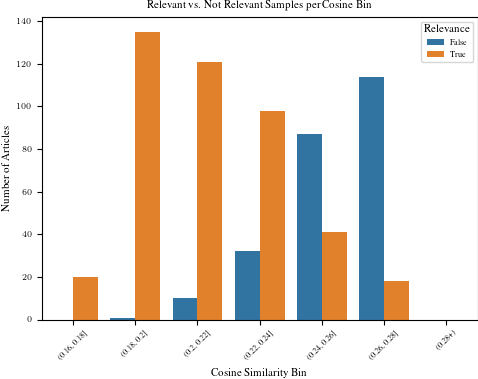

(364570, 8)
(604, 19)


In [42]:
plt.rcParams.update(bundles.icml2024(column='half', nrows=1, ncols=2))

fig = cos_bin_check(df_32_sampled, df_tag_valid)
plt.tight_layout()
plt.show() 
fig.savefig(f"{figure_output_path}fig_rel_cosbin.pdf", bbox_inches="tight")

print(df_32_nothresh.shape)
print(df_tag_nodups.shape)